In [257]:
from sklearn.datasets import load_breast_cancer, load_diabetes
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from PNN import TrainablePNN, PNN
from GRNN import GRNN, TrainableGRNN
from sklearn.linear_model import LogisticRegression, LinearRegression

import torch

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [259]:
def make_pca(X, y, name):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    explained_variance = pca.explained_variance_ratio_
    print(f"1st component explained variance: {explained_variance[0]:.2%}")
    print(f"2nd component explained variance: {explained_variance[1]:.2%}")
    print(f"1st and 2nd component explained variance: {explained_variance[:2].sum():.2%}")

    df = pd.DataFrame({
        'Component 1': X_pca[:, 0],
        'Component 2': X_pca[:, 1],
        'Class': y
    })
    
    sns.scatterplot(data=df, x='Component 1', y='Component 2', hue='Class')
    plt.xlabel(f"Component 1")
    plt.ylabel(f"Component 2")
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.savefig(f'./visualization/{name}')
    plt.show()

1030
1st component explained variance: 44.27%
2nd component explained variance: 18.97%
1st and 2nd component explained variance: 63.24%


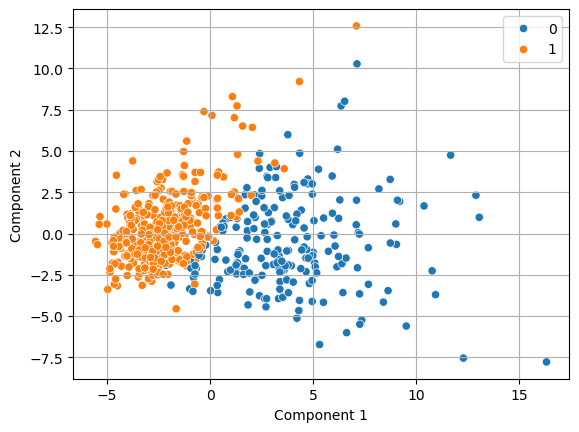

In [260]:
data = load_breast_cancer()
X = data['data']
y = data['target']
print(len(X_train))

make_pca(X, y, name='pca_breast_cancer.png')

1st component explained variance: 33.20%
2nd component explained variance: 13.22%
1st and 2nd component explained variance: 46.42%


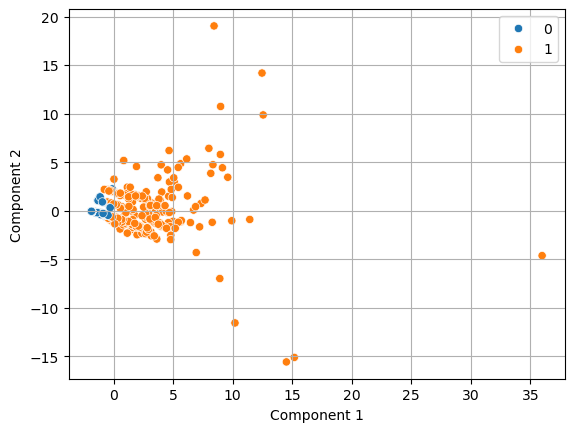

In [261]:
df = pd.read_csv('./data/audit_risk.csv')

df = df.dropna()

df = df.drop(columns=['LOCATION_ID'])

X = df.drop(columns=['Risk']).values
y = df['Risk'].values

make_pca(X, y, name='pca_audit_risk.png')

In [262]:
df = pd.read_csv('data/parkinsons.data')

1st component explained variance: 58.90%
2nd component explained variance: 11.30%
1st and 2nd component explained variance: 70.20%


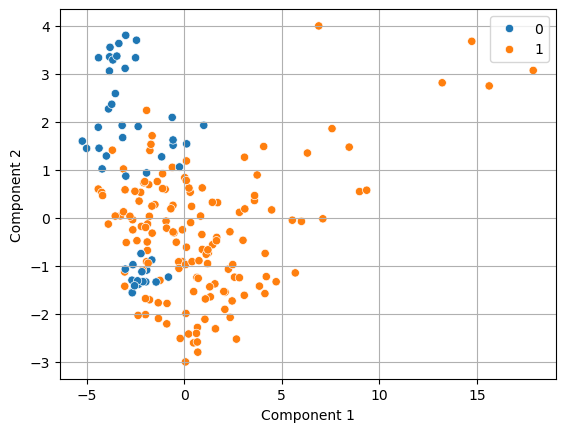

In [263]:
X = df.drop(columns=['name', 'status'])
y = df['status']
make_pca(X, y, name='pca_parkinsons.png')

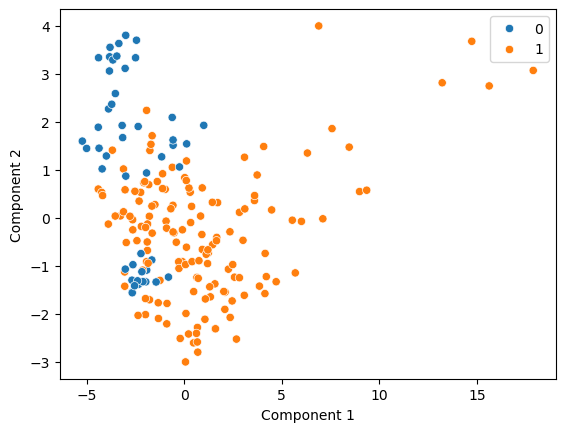

In [264]:
pnn = TrainablePNN(sigma=1.6, tau=4.3, regularization='l2', n_classes=2, losses=[1, 1])
lr = LogisticRegression()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pnn.fit(X_scaled, y)
lr.fit(X_scaled, y)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

grid = np.column_stack((xx.ravel(), yy.ravel()))
grid_original = pca.inverse_transform(grid)

Z_pnn = [pnn.predict(grid_point) for grid_point in grid_original]
Z_lr = lr.predict(grid_original)



df = pd.DataFrame({
    'Component 1': X_pca[:, 0],
    'Component 2': X_pca[:, 1],
    'Class': y
})

sns.scatterplot(data=df, x='Component 1', y='Component 2', hue='Class')
plt.xlabel(f"Component 1")
plt.ylabel(f"Component 2")
plt.legend(loc='upper right')
plt.show()

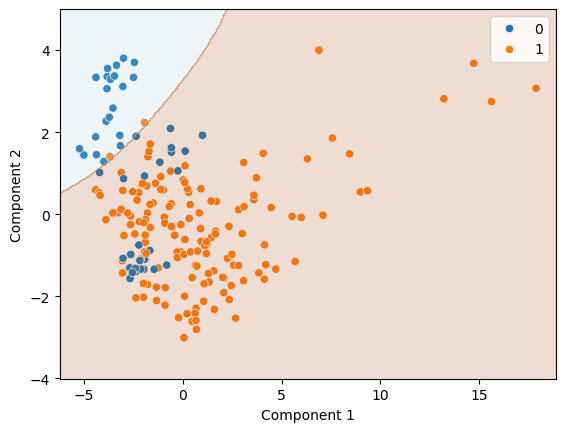

In [265]:
Z_pnn = np.array(Z_pnn).reshape(xx.shape)
Z_lr = np.array(Z_lr).reshape(xx.shape)

sns.scatterplot(data=df, x='Component 1', y='Component 2', hue='Class')
plt.contourf(xx, yy, Z_pnn, alpha=0.2, cmap='Paired')
plt.xlabel(f"Component 1")
plt.ylabel(f"Component 2")
plt.legend(loc='upper right'),
plt.savefig('./visualization/pnn_parkinsons_db.png')
plt.show()

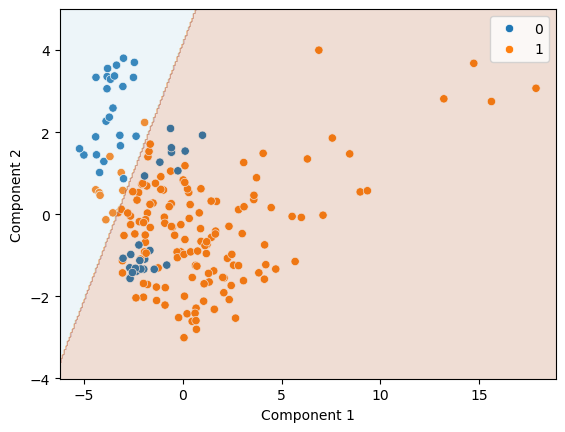

In [266]:
sns.scatterplot(data=df, x='Component 1', y='Component 2', hue='Class')
plt.contourf(xx, yy, Z_lr, alpha=0.2, cmap='Paired')
plt.xlabel(f"Component 1")
plt.ylabel(f"Component 2")
plt.legend(loc='upper right')
plt.savefig('./visualization/lr_parkinsons_db.png')
plt.show()

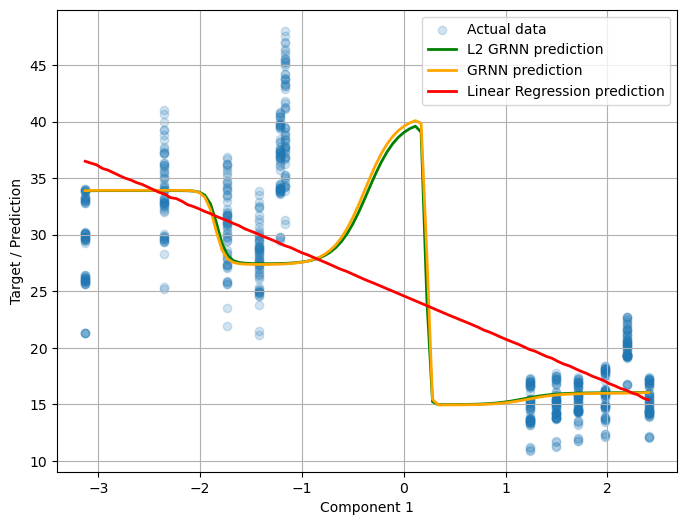

In [271]:
df = pd.read_csv('data/ENB2012_data.csv')

X = df.drop(columns=['Y1', 'Y2']).values
y = df['Y2'].to_numpy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

t_grnn = TrainableGRNN(sigma=0.2, tau=0.5, regularization='l2')
grnn = GRNN(sigma=0.2, kernel='gaussian')
t_grnn.fit(X_scaled, y_scaled)
grnn.fit(X_scaled, y_scaled)

lr = LinearRegression()
lr.fit(X_scaled, y_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pc1_min, pc1_max = X_pca[:, 0].min(), X_pca[:, 0].max()
pc1_range = np.linspace(pc1_min, pc1_max, 100)

pc2_mean = X_pca[:, 1].mean()
X_pca_line = np.column_stack((pc1_range, np.full_like(pc1_range, pc2_mean)))

X_line_orig = pca.inverse_transform(X_pca_line)

t_y_pred_grnn_line_scaled = np.array([t_grnn.predict([x_orig]) for x_orig in X_line_orig])
y_pred_grnn_line_scaled = np.array([grnn.predict([x_orig]) for x_orig in X_line_orig])

y_pred_lr_line_scaled = lr.predict(X_line_orig)

t_y_pred_grnn_line = scaler_y.inverse_transform(t_y_pred_grnn_line_scaled.reshape(-1, 1)).flatten()
y_pred_grnn_line = scaler_y.inverse_transform(y_pred_grnn_line_scaled.reshape(-1, 1)).flatten()
y_pred_lr_line = scaler_y.inverse_transform(y_pred_lr_line_scaled.reshape(-1, 1)).flatten()


plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], y, label='Actual data', alpha=0.2)
plt.plot(pc1_range, t_y_pred_grnn_line, color='green', label='L2 GRNN prediction', linewidth=2)
plt.plot(pc1_range, y_pred_grnn_line, color='orange', label='GRNN prediction', linewidth=2)
plt.plot(pc1_range, y_pred_lr_line, color='red', label='Linear Regression prediction', linewidth=2)
plt.xlabel('Component 1')
plt.ylabel('Target / Prediction')
plt.legend()
plt.savefig('./visualization/pca_grnn_energy.png')
plt.grid(True)
plt.show()

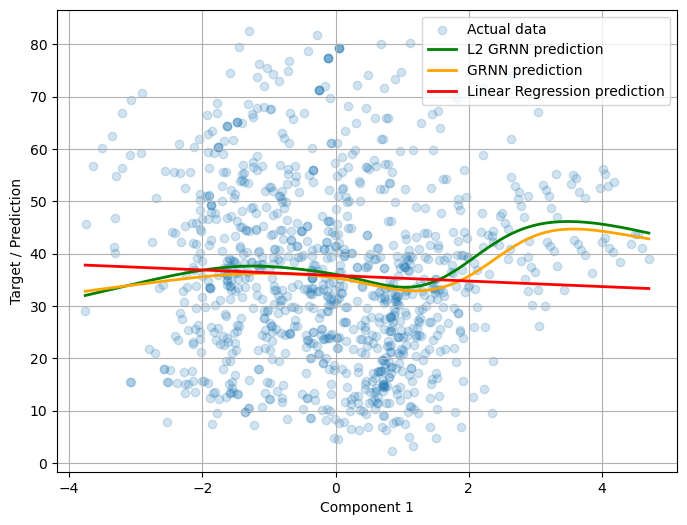

In [272]:
df = pd.read_excel('data/Concrete_Data.xls')

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

t_grnn = TrainableGRNN(sigma=0.7, regularization='l2', tau=3.3)
t_grnn.fit(X_scaled, y_scaled)
grnn = GRNN(sigma=0.7, kernel='gaussian')
grnn.fit(X_scaled, y_scaled)

lr = LinearRegression()
lr.fit(X_scaled, y_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pc1_min, pc1_max = X_pca[:, 0].min(), X_pca[:, 0].max()
pc1_range = np.linspace(pc1_min, pc1_max, 100)

pc2_mean = X_pca[:, 1].mean()
X_pca_line = np.column_stack((pc1_range, np.full_like(pc1_range, pc2_mean)))

X_line_orig = pca.inverse_transform(X_pca_line)

t_y_pred_grnn_line_scaled = np.array([t_grnn.predict([x_orig]) for x_orig in X_line_orig])
y_pred_grnn_line_scaled = np.array([grnn.predict([x_orig]) for x_orig in X_line_orig])

y_pred_lr_line_scaled = lr.predict(X_line_orig)

t_y_pred_grnn_line = scaler_y.inverse_transform(t_y_pred_grnn_line_scaled.reshape(-1, 1)).flatten()
y_pred_grnn_line = scaler_y.inverse_transform(y_pred_grnn_line_scaled.reshape(-1, 1)).flatten()
y_pred_lr_line = scaler_y.inverse_transform(y_pred_lr_line_scaled.reshape(-1, 1)).flatten()

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], y, label='Actual data', alpha=0.2)
plt.plot(pc1_range, t_y_pred_grnn_line, color='green', label='L2 GRNN prediction', linewidth=2)
plt.plot(pc1_range, y_pred_grnn_line, color='orange', label='GRNN prediction', linewidth=2)
plt.plot(pc1_range, y_pred_lr_line, color='red', label='Linear Regression prediction', linewidth=2)
plt.xlabel('Component 1')
plt.ylabel('Target / Prediction')
plt.legend()
plt.savefig('./visualization/pca_grnn_concrete.png')
plt.grid(True)
plt.show()

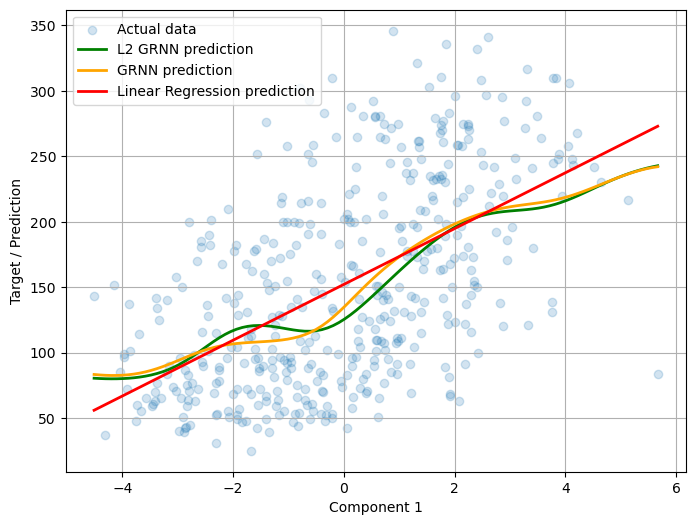

In [274]:
data = load_diabetes()

X = data['data']
y = data['target']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

t_grnn = TrainableGRNN(sigma=0.7, regularization='l2', tau=2.9)
t_grnn.fit(X_scaled, y_scaled)
grnn = GRNN(sigma=0.7, kernel='gaussian')
grnn.fit(X_scaled, y_scaled)

lr = LinearRegression()
lr.fit(X_scaled, y_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pc1_min, pc1_max = X_pca[:, 0].min(), X_pca[:, 0].max()
pc1_range = np.linspace(pc1_min, pc1_max, 100)

pc2_mean = X_pca[:, 1].mean()
X_pca_line = np.column_stack((pc1_range, np.full_like(pc1_range, pc2_mean)))

X_line_orig = pca.inverse_transform(X_pca_line)

t_y_pred_grnn_line_scaled = np.array([t_grnn.predict([x_orig]) for x_orig in X_line_orig])
y_pred_grnn_line_scaled = np.array([grnn.predict([x_orig]) for x_orig in X_line_orig])

y_pred_lr_line_scaled = lr.predict(X_line_orig)

t_y_pred_grnn_line = scaler_y.inverse_transform(t_y_pred_grnn_line_scaled.reshape(-1, 1)).flatten()
y_pred_grnn_line = scaler_y.inverse_transform(y_pred_grnn_line_scaled.reshape(-1, 1)).flatten()
y_pred_lr_line = scaler_y.inverse_transform(y_pred_lr_line_scaled.reshape(-1, 1)).flatten()

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], y, label='Actual data', alpha=0.2)
plt.plot(pc1_range, t_y_pred_grnn_line, color='green', label='L2 GRNN prediction', linewidth=2)
plt.plot(pc1_range, y_pred_grnn_line, color='orange', label='GRNN prediction', linewidth=2)
plt.plot(pc1_range, y_pred_lr_line, color='red', label='Linear Regression prediction', linewidth=2)
plt.xlabel('Component 1')
plt.ylabel('Target / Prediction')
plt.legend()
plt.savefig('./visualization/pca_grnn_diabetes.png')
plt.grid(True)
plt.show()